# 自动特征分析报告

本 Notebook 演示如何使用 `auto_feature_analysis_report` 函数生成自动化特征分析报告。

数据来源: hscredit.xlsx（百融数据）

In [1]:
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')

import pandas as pd
import numpy as np
from hscredit.report import auto_feature_analysis_report
from hscredit import *

init_setting()

In [2]:
# 加载数据
data_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/hscredit.xlsx'
df = pd.read_excel(data_path)
print(f"数据形状: {df.shape}")
df.head()

数据形状: (22729, 12)


,MOB1,MOB2,青云24,游昆定制分80,百融定制分V9,中智小牛分C3,度小满欺诈因子V6PRO多头版,百行百川分FPV1,设备黑名单,放款期数,放款期数,放款期数
0,0,0,612.0000,718.0000,914.7400,687.0000,NaN,NaN,2.0000,STORE,LYX_DX,6
1,0,0,640.0000,718.0000,894.2800,774.0000,NaN,NaN,3.0000,STORE,RENPIN_XXK,6
2,0,0,581.0000,709.0000,822.1200,629.0000,53.3800,306.0000,3.0000,STORE,LYX_DX,6
3,0,0,650.0000,718.0000,794.5000,662.0000,48.6500,285.0000,3.0000,STORE,LYX_DX,6
4,0,0,650.0000,718.0000,794.5000,662.0000,48.6500,285.0000,3.0000,STORE,LYX_DX,6


In [3]:
# 创建目标变量
# 使用 MOB2（逾期月数）来判断：如果 MOB2 > 0 则为坏客户
df['target'] = (df['MOB2'] > 0).astype(int)

print("目标变量分布:")
print(df['target'].value_counts())
print(f"\n坏客户比例: {df['target'].mean():.2%}")

目标变量分布:
target
0    17474
1     5255
Name: count, dtype: int64

坏客户比例: 23.12%


In [4]:
# 选择要分析的特征（数值型特征）
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
features = [c for c in numeric_cols if c not in ['target', 'MOB1', 'MOB2']]

print("待分析特征:")
for f in features:
    print(f"  - {f}")

待分析特征:
  - 青云24
  - 游昆定制分80
  - 百融定制分V9
  - 中智小牛分C3
  - 度小满欺诈因子V6PRO多头版
  - 百行百川分FPV1
  - 设备黑名单
  - 放款期数


In [5]:
# 定义特征名称映射（可选）
feature_map = {
    '青云24': '青云评分',
    '游昆定制分80': '游昆评分',
    '百融定制分V9': '百融评分',
    '中智小牛分C3': '中智评分',
    '度小满欺诈因子V6PRO多头版': '度小满欺诈分',
    '百行百川分FPV1': '百行评分',
    '设备黑名单': '设备黑名单',
    '放款期数': '贷款期数'
}

100%|██████████| 8/8 [00:11<00:00,  1.39s/it, feature=贷款期数]    


报告生成完成！结束位置: (282, 37)


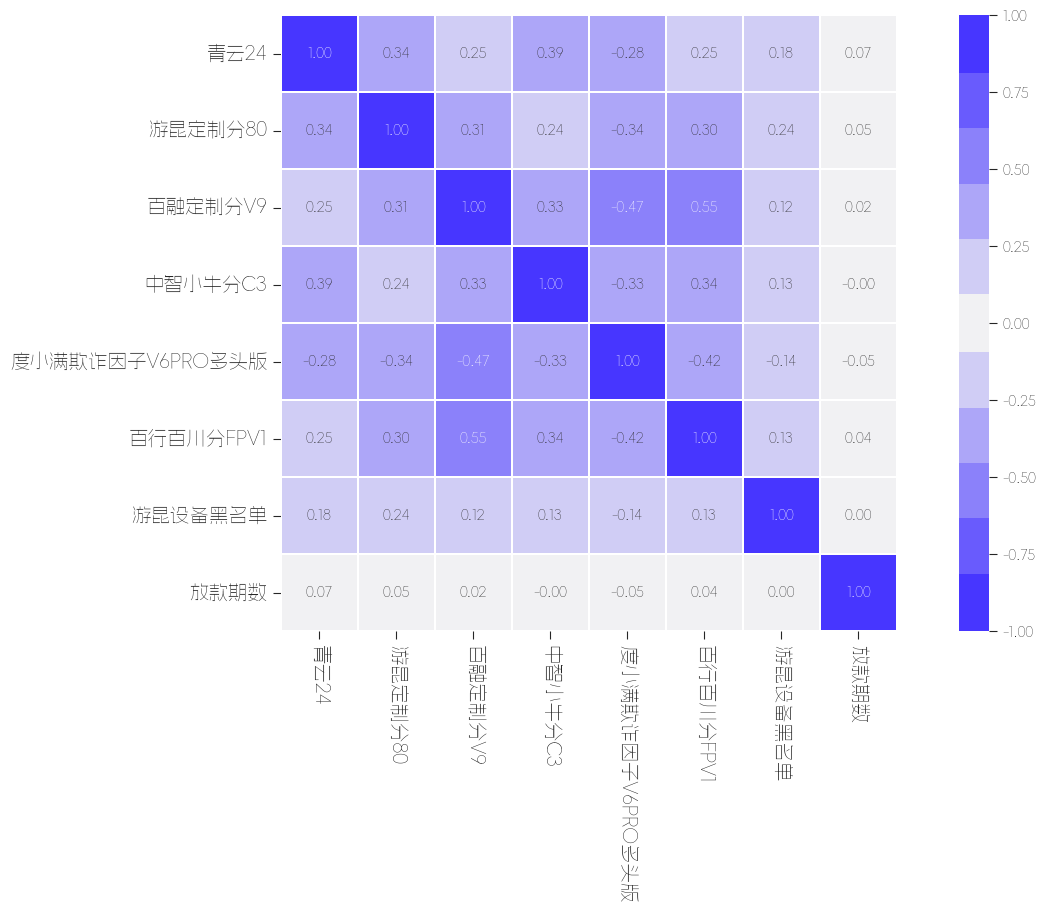

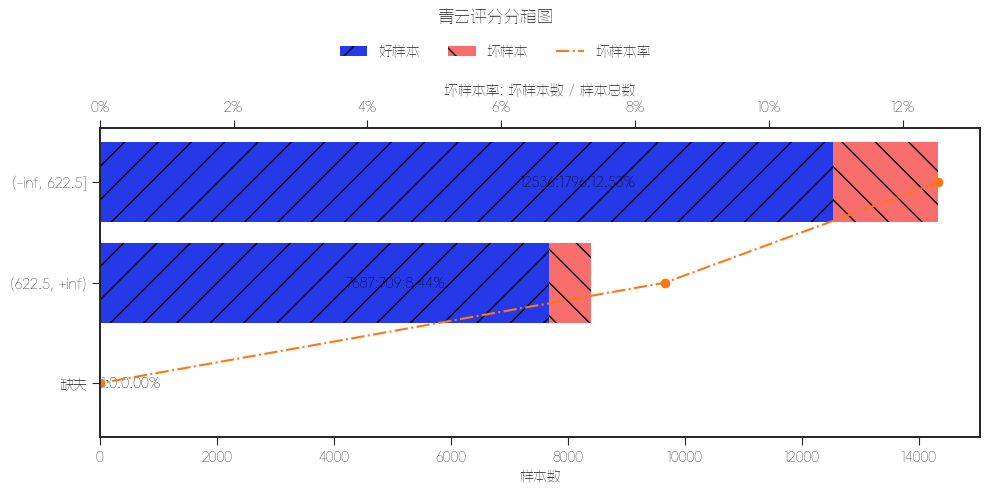

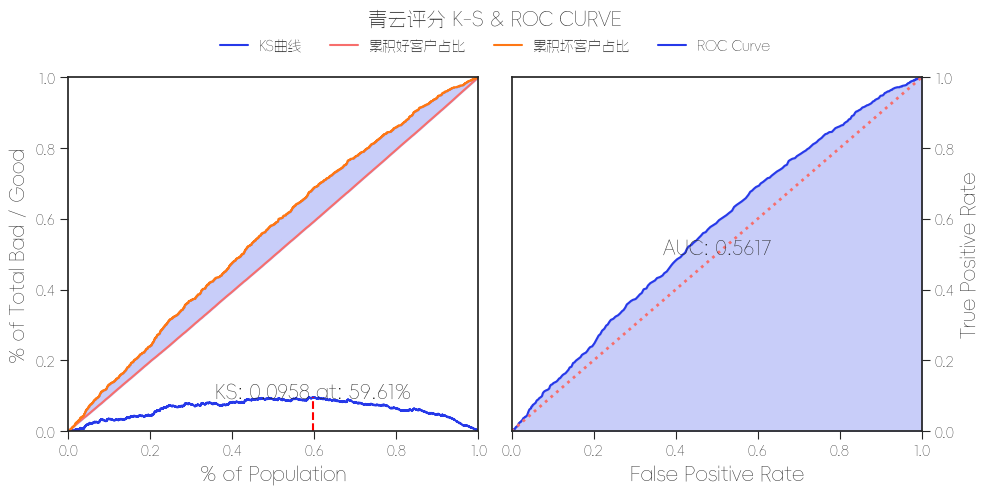

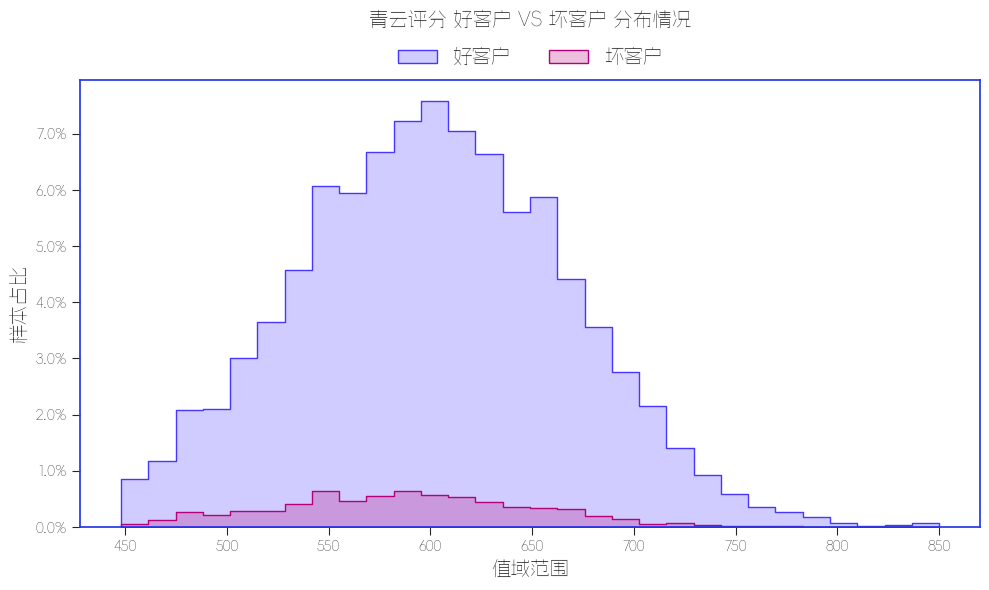

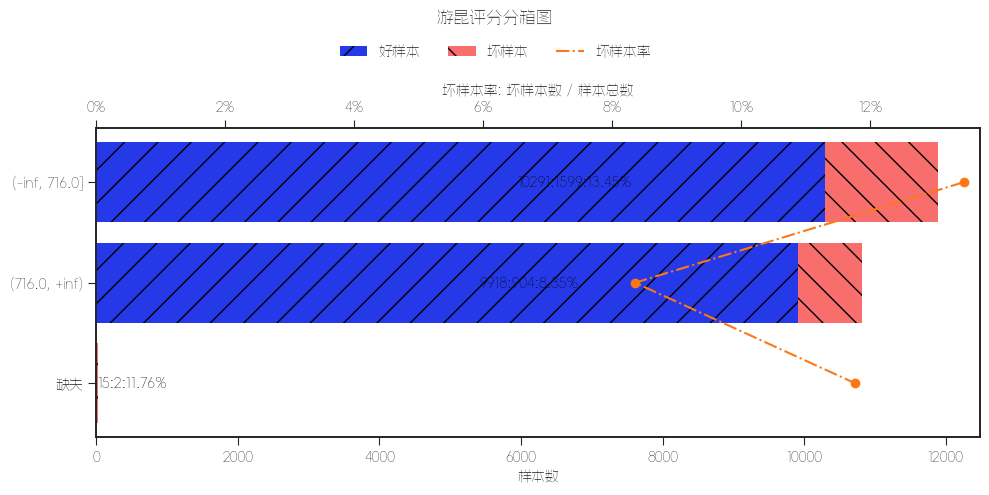

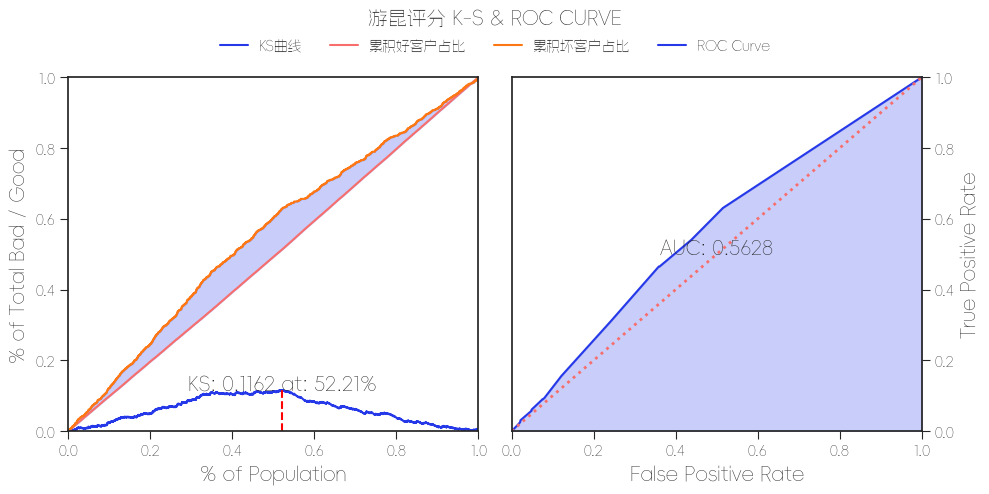

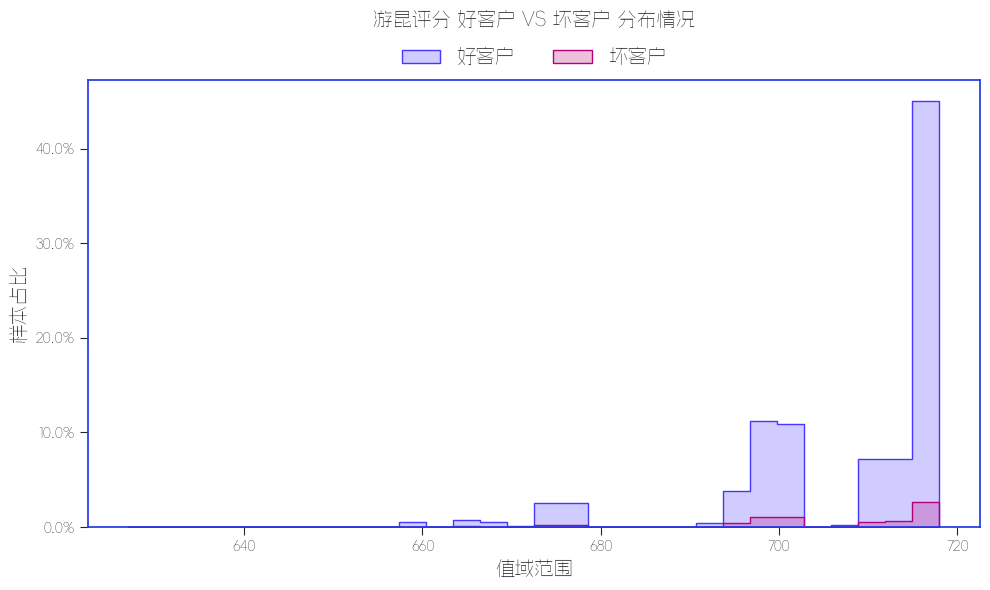

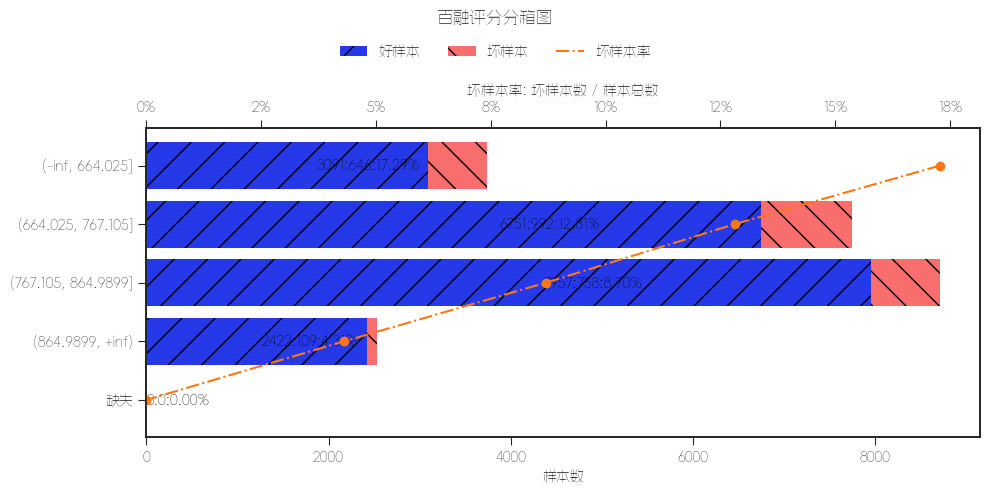

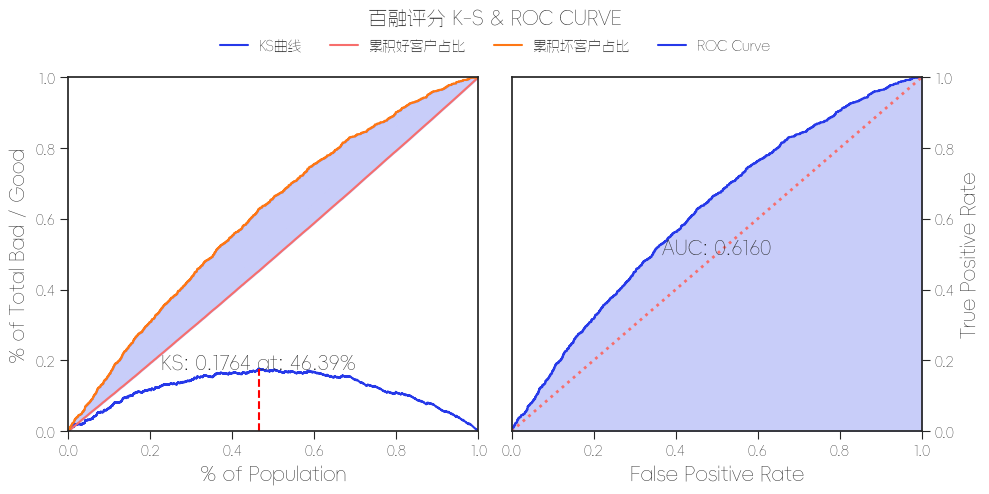

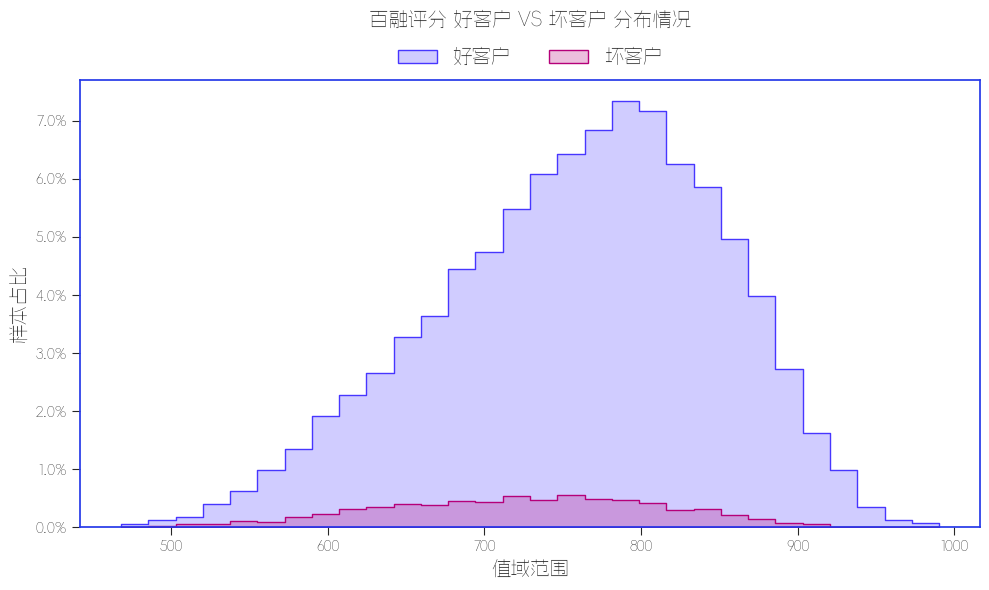

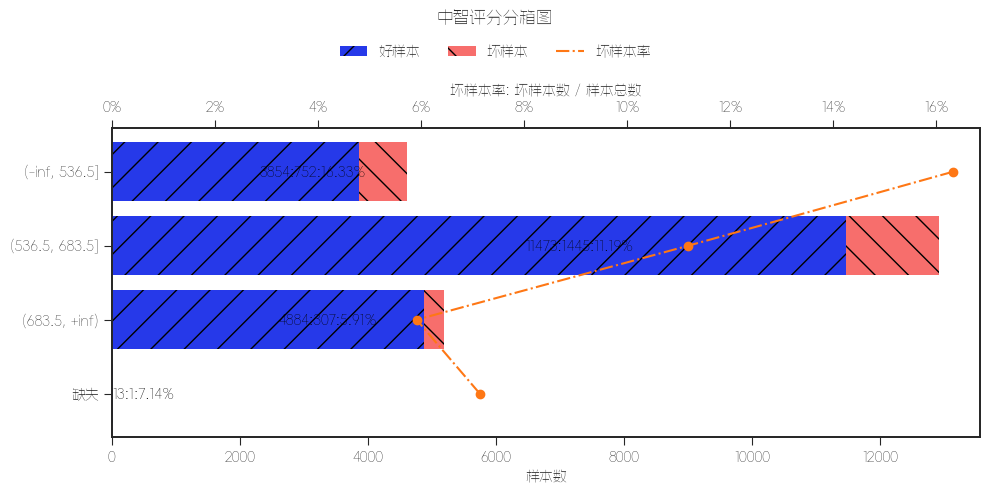

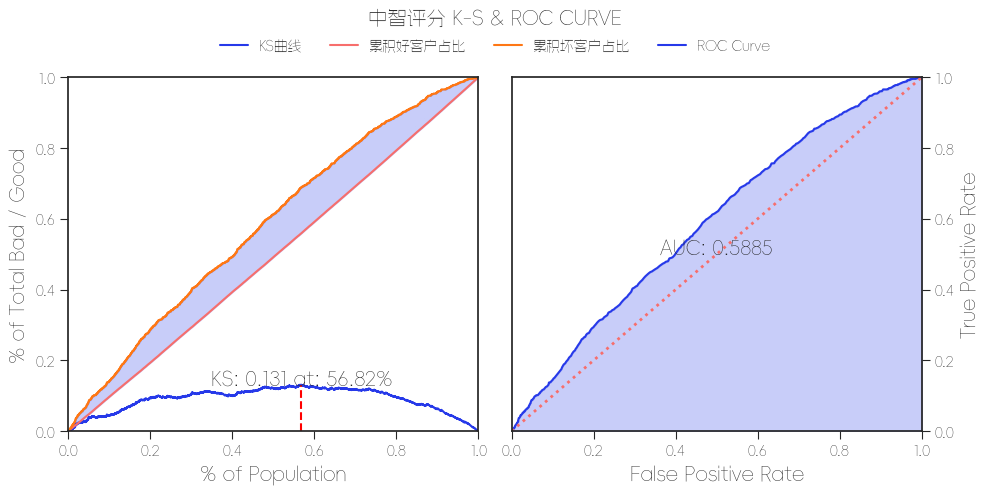

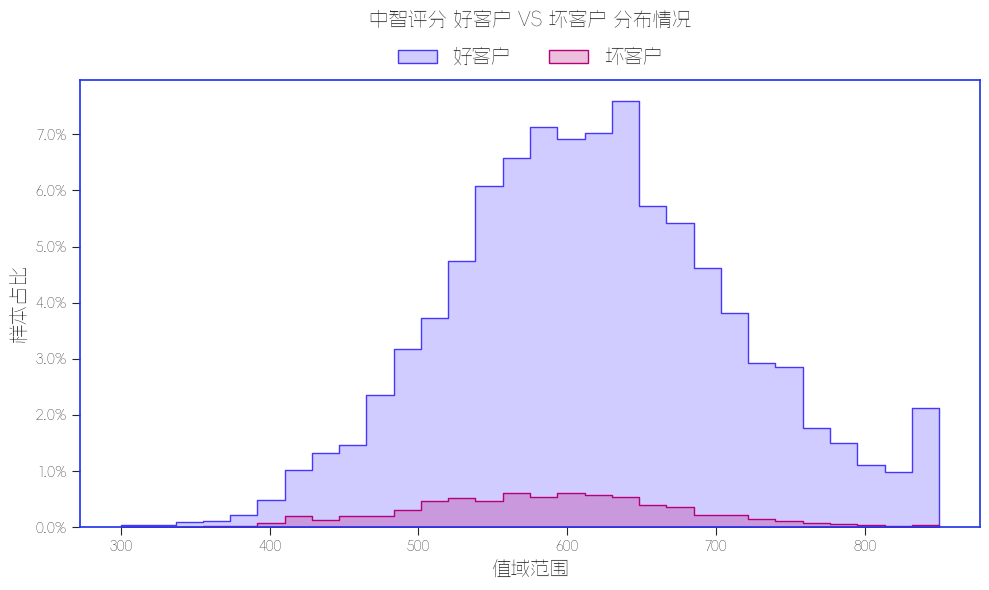

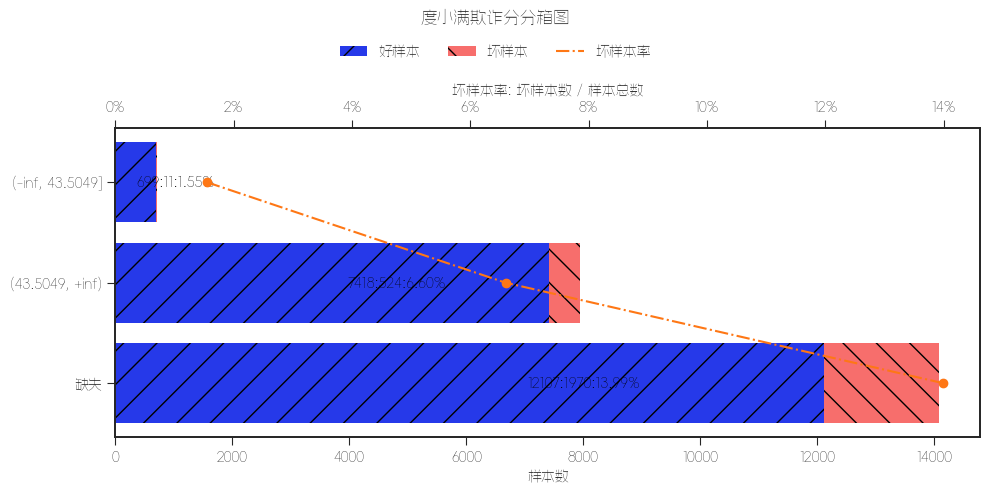

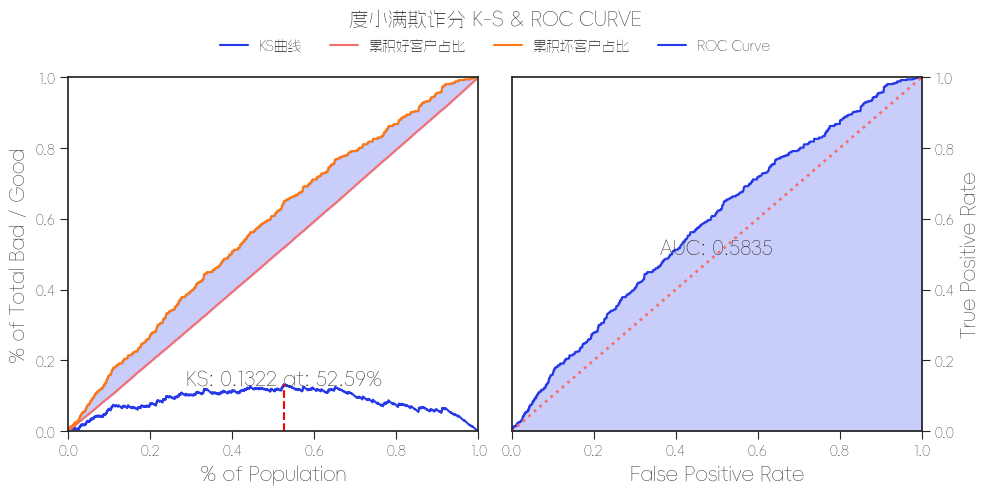

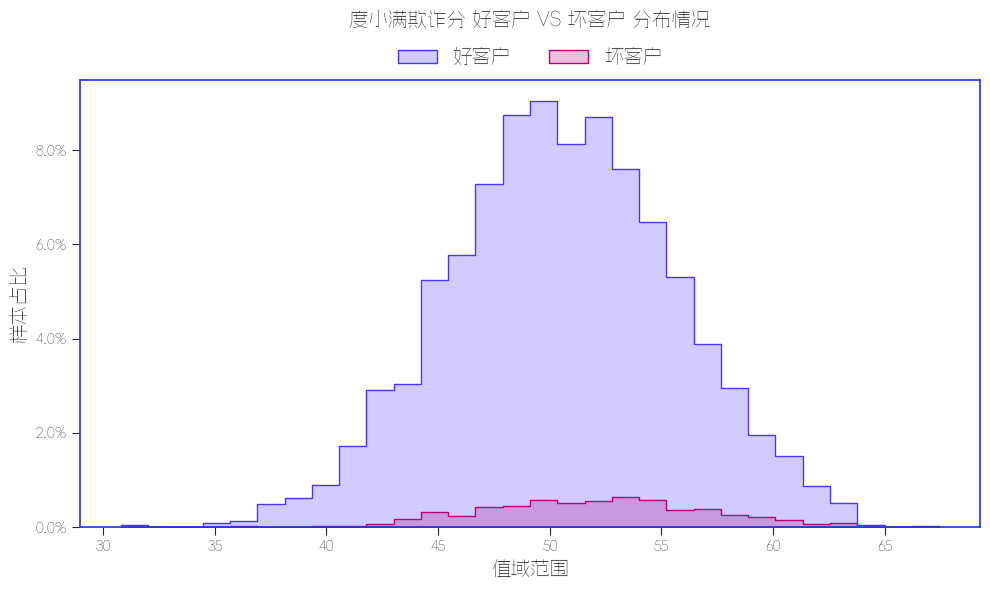

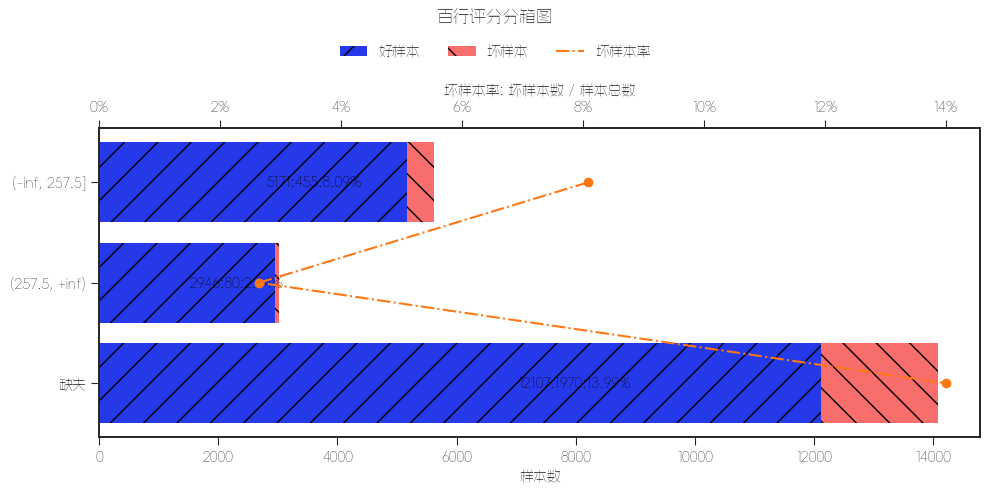

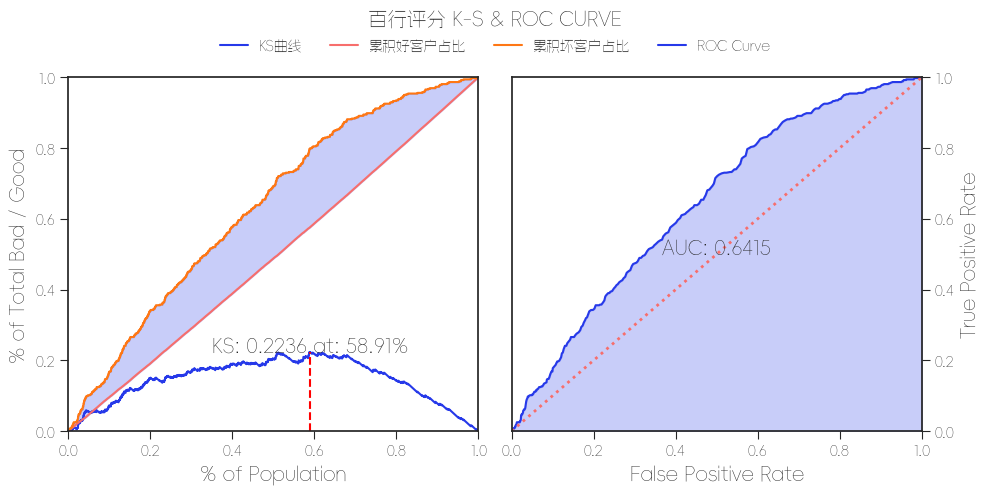

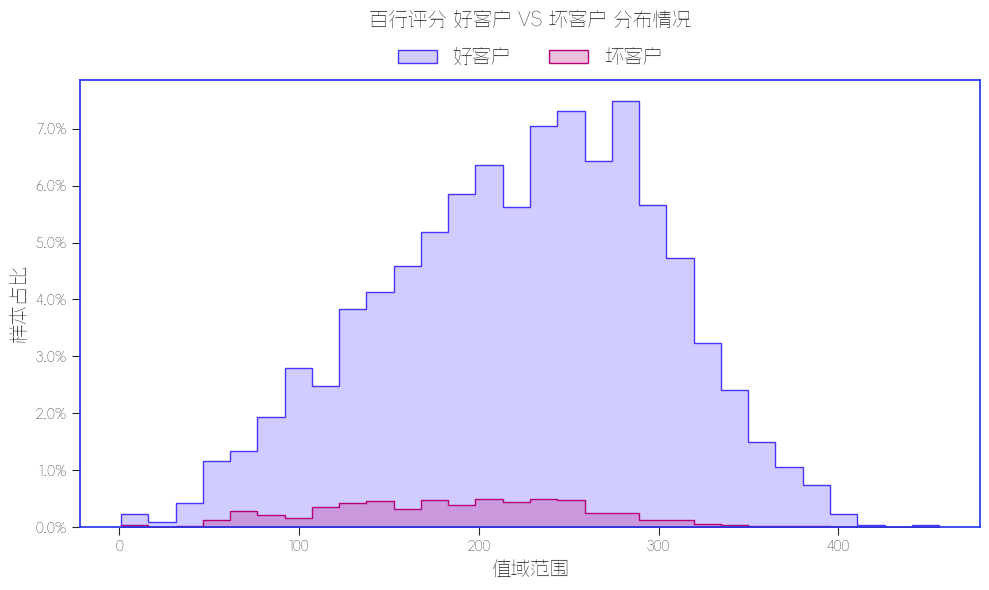

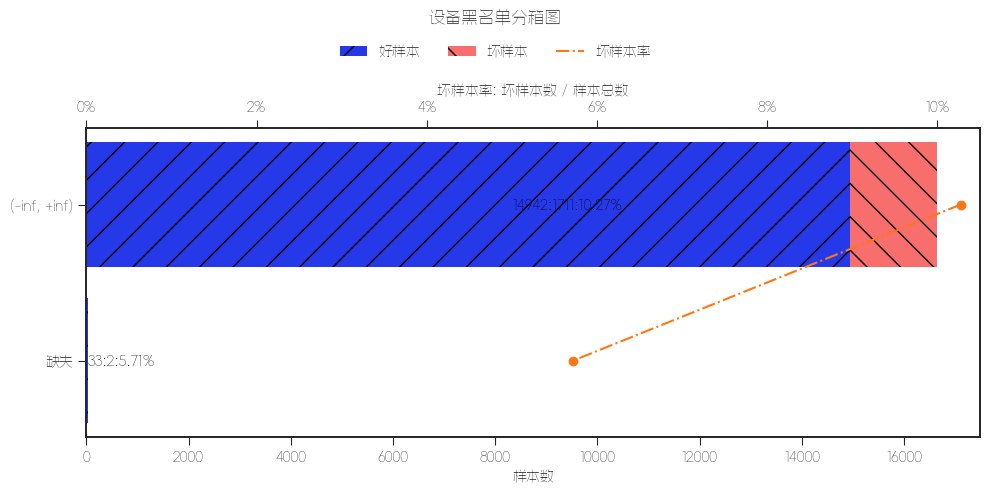

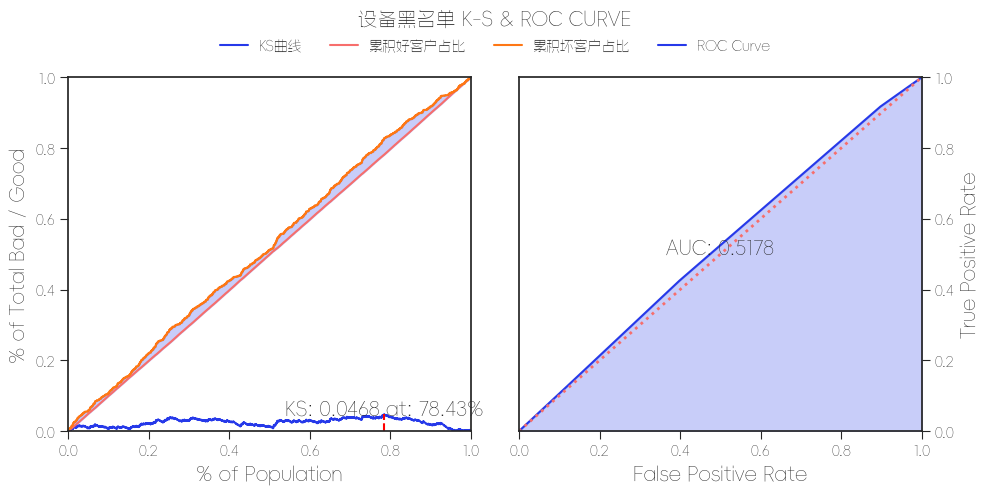

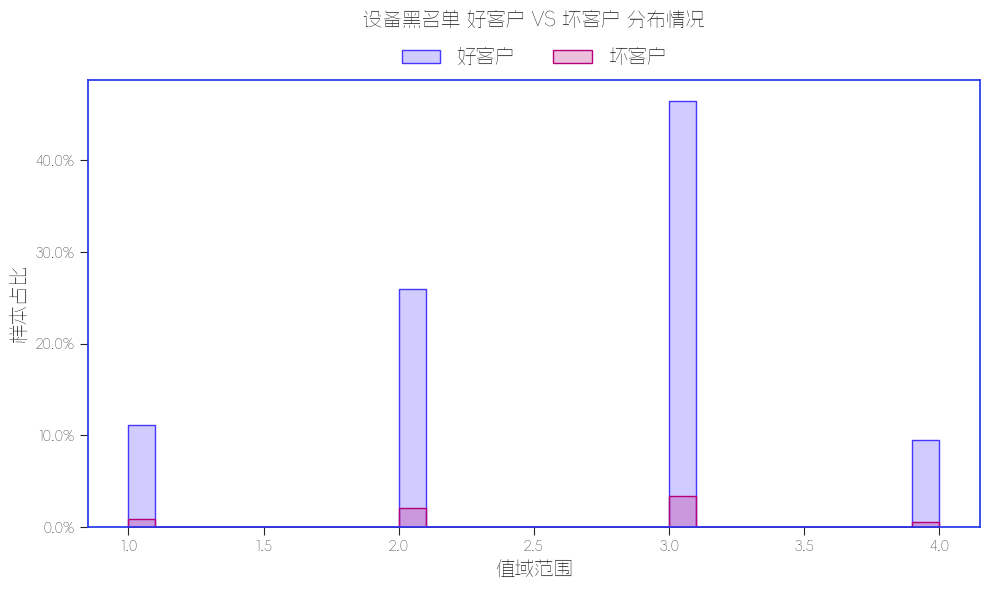

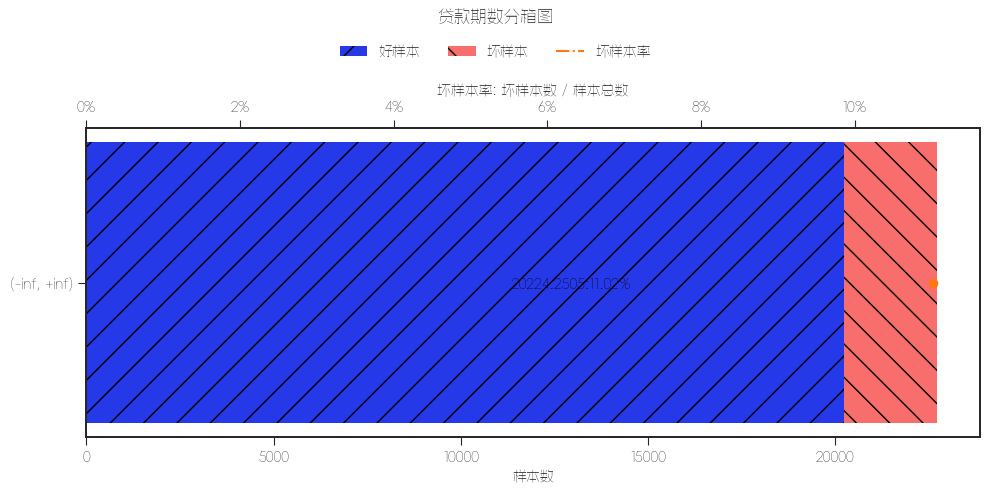

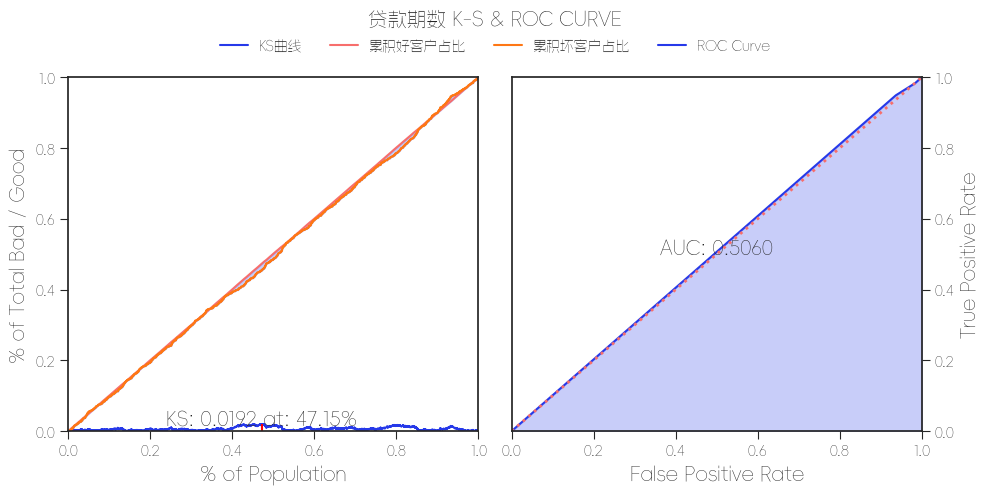

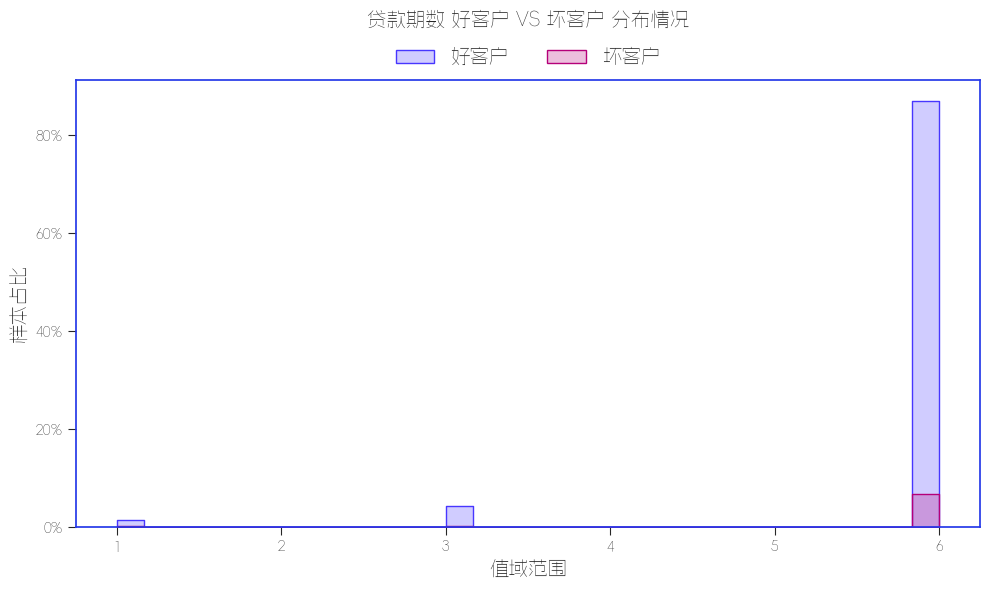

In [8]:
# 生成自动特征分析报告
report_result = auto_feature_analysis_report(
    data=df,
    features=features,
    overdue=['MOB1', 'MOB2'],
    dpds=[15],
    feature_map=feature_map,
    corr=True,                    # 计算特征相关性
    pictures=['bin', 'ks', 'hist'],  # 生成图片
    excel_writer='./outputs/特征分析报告.xlsx',
    output_dir='./outputs/feature_report'
)

print(f"报告生成完成！结束位置: {report_result}")

## 报告内容说明

生成的 Excel 报告包含以下内容：

1. **样本总体分布情况**: 数据集基本信息，包括样本总数、坏客户数、坏客户占比等
2. **数值类变量相关性**: 特征之间的相关性矩阵热力图
3. **数值类特征 OR 评分效果评估**: 针对每个特征的详细分析
   - 特征分箱统计表（WOE、IV、LIFT等）
   - 特征分箱可视化图
   - KS曲线图
   - 好客户 VS 坏客户分布直方图

In [7]:
# 查看生成的图片
import os
report_dir = 'feature_report'
print("生成的文件列表:")
for f in sorted(os.listdir(report_dir)):
    print(f"  - {f}")

生成的文件列表:


FileNotFoundError: [Errno 2] No such file or directory: 'feature_report'